Now we start answering business questions.

Not machine learning.

Not hypothesis tests.

Not Power BI.

First, we need to understand customer behavior.

First question:
What does a typical customer session look like?
Metrics:

click_count
unique_products
unique_categories
max_page

Plots:

Histogram of click_count
Boxplot of click_count

Goal:

Understand customer engagement

# Exploratory Product Analytics

## Objective

This notebook explores session-level customer behaviour and identifies
product-presentation factors that may be suitable for future A/B tests.

The analysis focuses on:

1. Typical browsing-session behaviour
2. Engagement by first product category
3. Engagement by photography type
4. Engagement by product location
5. Potential experiment opportunities

Because the original data are observational rather than randomized,
the results describe associations and should not be interpreted as
causal A/B-test effects.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data_path = Path("../data/processed/session_summary.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"Session dataset not found at: {data_path.resolve()}"
    )

session_df = pd.read_csv(data_path)

print(f"Rows: {session_df.shape[0]:,}")
print(f"Columns: {session_df.shape[1]}")

Rows: 24,026
Columns: 14


In [4]:
session_df.head()

,session_id,click_count,unique_products,unique_categories,max_page,average_price,max_order,first_category,first_photo,first_location,first_category_name,first_photo_name,first_location_name,engagement_score
0,1,9,9,4,5,42.111111,9,1,1,5,Trousers,Front View,Bottom Middle,27
1,2,10,8,3,2,50.000000,10,2,1,5,Skirts,Front View,Bottom Middle,23
2,3,6,6,3,5,42.166667,6,2,2,6,Skirts,Profile View,Bottom Right,20
3,4,4,4,2,3,45.250000,4,1,1,6,Trousers,Front View,Bottom Right,13
4,5,1,1,1,2,57.000000,1,3,1,1,Blouses,Front View,Top Left,5


In [5]:
session_df.isnull().sum()

session_id             0
click_count            0
unique_products        0
unique_categories      0
max_page               0
average_price          0
max_order              0
first_category         0
first_photo            0
first_location         0
first_category_name    0
first_photo_name       0
first_location_name    0
engagement_score       0
dtype: int64

In [6]:
engagement_columns = [
    "click_count",
    "unique_products",
    "unique_categories",
    "max_page",
    "average_price"
]

session_df[engagement_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
click_count,24026.0,6.887289,8.995161,1.0,2.000000,4.000000,8.0,195.0
unique_products,24026.0,6.174353,7.525282,1.0,2.000000,4.000000,8.0,168.0
unique_categories,24026.0,1.851661,0.956479,1.0,1.000000,2.000000,3.0,4.0
max_page,24026.0,2.250271,1.284408,1.0,1.000000,2.000000,3.0,5.0
average_price,24026.0,44.374906,8.454850,18.0,38.166667,43.666667,49.0,82.0


In [7]:
typical_session = pd.Series({
    "Total sessions": session_df["session_id"].nunique(),
    "Average clicks": session_df["click_count"].mean(),
    "Median clicks": session_df["click_count"].median(),
    "Average unique products": session_df["unique_products"].mean(),
    "Average unique categories": session_df["unique_categories"].mean(),
    "Average maximum page": session_df["max_page"].mean(),
    "Average viewed price": session_df["average_price"].mean()
})

typical_session.round(2)

Total sessions               24026.00
Average clicks                   6.89
Median clicks                    4.00
Average unique products          6.17
Average unique categories        1.85
Average maximum page             2.25
Average viewed price            44.37
dtype: float64

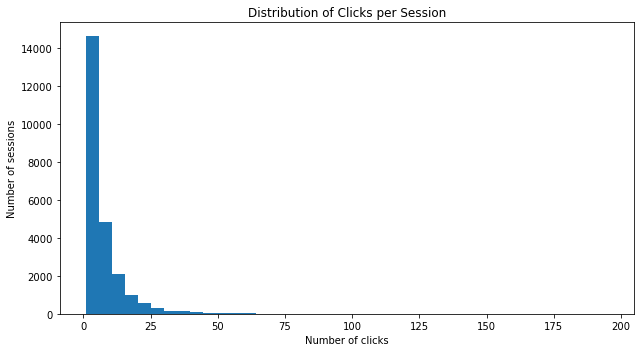

In [8]:
plt.figure(figsize=(9, 5))

plt.hist(
    session_df["click_count"],
    bins=40
)

plt.title("Distribution of Clicks per Session")
plt.xlabel("Number of clicks")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()

In [ ]:
# Typical session
click_limit = session_df["click_count"].quantile(0.99)

typical_sessions = session_df[
    session_df["click_count"] <= click_limit
]

print(f"99th-percentile limit: {click_limit:.0f} clicks")
print(f"Sessions displayed: {len(typical_sessions):,}")

99th-percentile limit: 42 clicks
Sessions displayed: 23,801


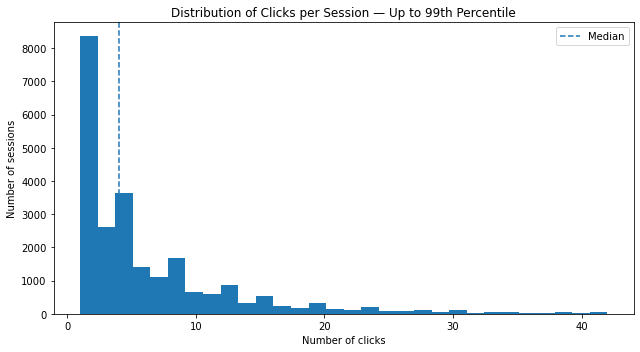

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    typical_sessions["click_count"],
    bins=30
)

plt.axvline(
    typical_sessions["click_count"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Clicks per Session — Up to 99th Percentile")
plt.xlabel("Number of clicks")
plt.ylabel("Number of sessions")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
 # Measure the right tail
 long_session_threshold = session_df["click_count"].quantile(0.95)

session_df["is_long_session"] = (
    session_df["click_count"] > long_session_threshold
)

long_session_summary = (
    session_df["is_long_session"]
    .value_counts()
    .rename(index={
        False: "Typical session",
        True: "Long session"
    })
)

long_session_summary

Typical session    22920
Long session        1106
Name: is_long_session, dtype: int64

## Typical-session findings

- The session-level dataset contains **24,026 customer visits**.
- A session contains an average of **[mean] clicks**, while the median is
  **[median] clicks**.
- The mean is higher than the median, indicating a right-skewed
  distribution caused by a relatively small number of long sessions.
- Most visitors browse only a few products, while a minority exhibit
  substantially higher engagement.
- Sessions above the 95th percentile are labelled as long sessions for
  later exploratory comparisons.

In [12]:
category_engagement = (
    session_df.groupby("first_category_name")
    .agg(
        sessions=("session_id", "count"),
        mean_clicks=("click_count", "mean"),
        median_clicks=("click_count", "median"),
        q1_clicks=("click_count", lambda x: x.quantile(0.25)),
        q3_clicks=("click_count", lambda x: x.quantile(0.75)),
        max_clicks=("click_count", "max")
    )
    .sort_values("median_clicks", ascending=False)
)

category_engagement.round(2)

,sessions,mean_clicks,median_clicks,q1_clicks,q3_clicks,max_clicks
first_category_name,,,,,,
Trousers,9247,7.91,5.0,2.0,10.0,195
Sale,3862,7.21,4.0,2.0,9.0,120
Blouses,4445,5.99,3.0,1.0,7.0,192
Skirts,6472,5.85,3.0,2.0,7.0,128


In [ ]:
### Business Insight 1

Browsing sessions that begin in the **Trousers** category show the highest engagement.

These sessions have both the highest average number of clicks (7.91) and the highest median number of clicks (5), suggesting that the finding is not driven solely by a small number of extreme sessions.

Sessions beginning in the **Sale** category also demonstrate relatively high engagement, while **Blouses** and **Skirts** show shorter browsing sessions.

These findings suggest that the initial product category may influence subsequent customer engagement and should be considered when prioritizing future product-page experiments.
### Trousers are associated with higher engagement.

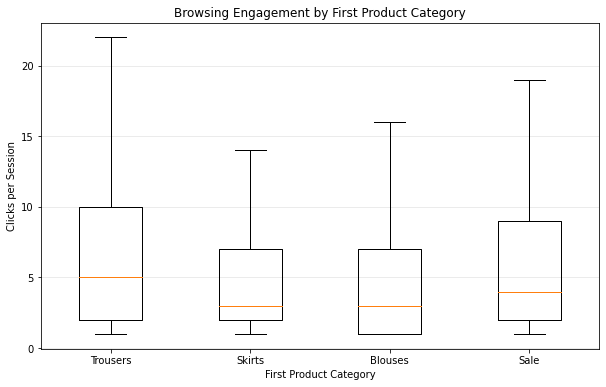

In [13]:
## Do customers who start in different product categories exhibit different browsing behaviour?
plt.figure(figsize=(10,6))

plt.boxplot(
    [
        session_df.loc[
            session_df["first_category_name"]=="Trousers",
            "click_count"
        ],
        session_df.loc[
            session_df["first_category_name"]=="Skirts",
            "click_count"
        ],
        session_df.loc[
            session_df["first_category_name"]=="Blouses",
            "click_count"
        ],
        session_df.loc[
            session_df["first_category_name"]=="Sale",
            "click_count"
        ]
    ],
    labels=["Trousers","Skirts","Blouses","Sale"],
    showfliers=False
)

plt.title("Browsing Engagement by First Product Category")
plt.xlabel("First Product Category")
plt.ylabel("Clicks per Session")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [14]:
category_summary = (
    session_df.groupby("first_category_name")
    .agg(
        sessions=("session_id","count"),
        mean_clicks=("click_count","mean"),
        median_clicks=("click_count","median")
    )
    .reset_index()
)

category_summary

,first_category_name,sessions,mean_clicks,median_clicks
0,Blouses,4445,5.993251,3.0
1,Sale,3862,7.213879,4.0
2,Skirts,6472,5.845179,3.0
3,Trousers,9247,7.910025,5.0


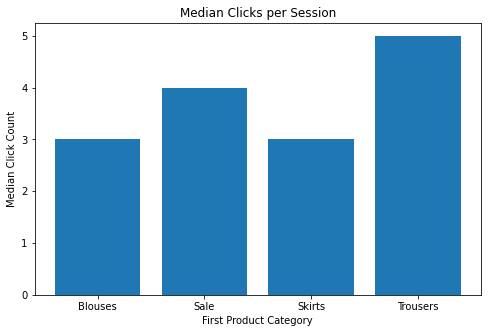

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    category_summary["first_category_name"],
    category_summary["median_clicks"]
)

plt.title("Median Clicks per Session")
plt.xlabel("First Product Category")
plt.ylabel("Median Click Count")

plt.show()

### Interpretation

The distribution of session engagement differs across the initial product categories.

Sessions beginning in the **Trousers** category exhibit the highest typical engagement, with a median of **5 clicks per session**, followed by **Sale** with **4 clicks**. Sessions starting in **Blouses** and **Skirts** have lower median engagement, both at **3 clicks**.

The boxplot further shows that the Trousers category has a wider interquartile range, indicating greater variability in customer browsing behaviour. While some users leave after only a few clicks, others continue exploring a substantially larger number of products.

Importantly, the higher engagement observed for Trousers is reflected in both the mean and the median, suggesting that the pattern is not explained solely by a small number of unusually long browsing sessions.

Because these data are observational, the results demonstrate an association rather than a causal effect. Nevertheless, the findings suggest that the initial product category may influence subsequent browsing behaviour and therefore represents a promising candidate for future controlled A/B testing.

H₀: The distributions (or equivalently, the typical ranks) of click counts are the same across all first product categories.
H₁: At least one category differs.

In [16]:
from scipy.stats import kruskal

c:\Users\eier\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [17]:
trousers = session_df.loc[
    session_df["first_category_name"] == "Trousers",
    "click_count"
]

skirts = session_df.loc[
    session_df["first_category_name"] == "Skirts",
    "click_count"
]

blouses = session_df.loc[
    session_df["first_category_name"] == "Blouses",
    "click_count"
]

sale = session_df.loc[
    session_df["first_category_name"] == "Sale",
    "click_count"
]

In [18]:
statistic, p_value = kruskal(
    trousers,
    skirts,
    blouses,
    sale
)

print(f"Kruskal-Wallis statistic: {statistic:.3f}")
print(f"P-value: {p_value:.6f}")

Kruskal-Wallis statistic: 303.738
P-value: 0.000000


In [19]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


The Kruskal–Wallis test indicates a statistically significant difference in session engagement among the four initial product categories (p < 0.05).

Therefore, at least one category exhibits a different distribution of click counts.

To identify which categories differ, post hoc pairwise comparisons will be performed.
There is very strong statistical evidence that browsing engagement differs among the four first product categories.

We have 24,026 sessions.

With such a large sample, even small differences can become statistically significant. Therefore, the next question is:
Are these differences large enough to matter from a business perspective?
This is why we need an effect size.

In [20]:
H = 303.738
k = 4
n = len(session_df)

epsilon_squared = (H - k + 1) / (n - k)

print(f"Epsilon squared: {epsilon_squared:.4f}")

Epsilon squared: 0.0125


The first product category explains only a small proportion of the variation in customer engagement. 
The first product category is statistically associated with customer engagement, but the magnitude of this association is relatively small.

### Statistical Interpretation

A Kruskal–Wallis test showed a statistically significant difference in click-count distributions across the four first product categories (H = 303.74, p < 0.001).

However, the estimated effect size was small (ε² = 0.0125), indicating that although the association is unlikely to be due to random sampling variation, the first product category alone explains only a small proportion of the variability in customer engagement.

This suggests that browsing behaviour is influenced by multiple factors beyond the initial product category.

In [21]:
!pip install scikit-posthocs

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\eier\\anaconda3\\Lib\\site-packages\\~cipy\\integrate\\lsoda.cp39-win_amd64.pyd'
Consider using the `--user` option or check the permissions.




  Attempting uninstall: scipy
    Found existing installation: scipy 1.7.3
    Uninstalling scipy-1.7.3:
      Successfully uninstalled scipy-1.7.3


In [23]:
import sys

print(sys.executable)

c:\Users\eier\anaconda3\python.exe


In [24]:
import sys

!{sys.executable} -m pip install scikit-posthocs

  Using cached scikit_posthocs-0.14.0-py3-none-any.whl (36 kB)


In [5]:
import scikit_posthocs as sp

In [6]:
dunn_results = sp.posthoc_dunn(
    session_df,
    val_col="click_count",
    group_col="first_category_name",
    p_adjust="holm"
)

dunn_results

,Blouses,Sale,Skirts,Trousers
Blouses,1.000000e+00,1.441629e-17,1.214028e-01,1.488334e-44
Sale,1.441629e-17,1.000000e+00,7.233576e-15,9.942934e-04
Skirts,1.214028e-01,7.233576e-15,1.000000e+00,3.795765e-44
Trousers,1.488334e-44,9.942934e-04,3.795765e-44,1.000000e+00


In [7]:
dunn_results.round(4)

,Blouses,Sale,Skirts,Trousers
Blouses,1.0000,0.000,0.1214,0.000
Sale,0.0000,1.000,0.0000,0.001
Skirts,0.1214,0.000,1.0000,0.000
Trousers,0.0000,0.001,0.0000,1.000


In [8]:
significant = dunn_results < 0.05

significant

,Blouses,Sale,Skirts,Trousers
Blouses,False,True,False,True
Sale,True,False,True,True
Skirts,False,True,False,True
Trousers,True,True,True,False


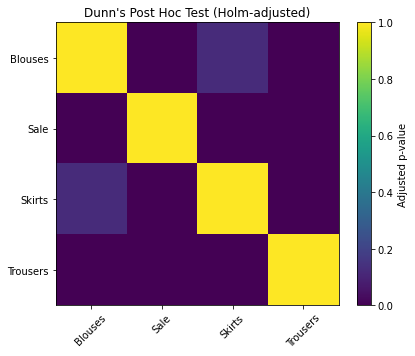

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(dunn_results, interpolation="nearest")

plt.colorbar(label="Adjusted p-value")

plt.xticks(
    range(len(dunn_results.columns)),
    dunn_results.columns,
    rotation=45
)

plt.yticks(
    range(len(dunn_results.index)),
    dunn_results.index
)

plt.title("Dunn's Post Hoc Test (Holm-adjusted)")

plt.tight_layout()

plt.show()

In [10]:
pairs = []

categories = dunn_results.columns

for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        pairs.append({
            "Comparison": f"{categories[i]} vs {categories[j]}",
            "Adjusted p-value": dunn_results.iloc[i, j],
            "Significant": dunn_results.iloc[i, j] < 0.05
        })

pairwise_results = pd.DataFrame(pairs)

pairwise_results

,Comparison,Adjusted p-value,Significant
0,Blouses vs Sale,1.441629e-17,True
1,Blouses vs Skirts,1.214028e-01,False
2,Blouses vs Trousers,1.488334e-44,True
3,Sale vs Skirts,7.233576e-15,True
4,Sale vs Trousers,9.942934e-04,True
5,Skirts vs Trousers,3.795765e-44,True


### Pairwise Comparisons

Dunn's post hoc test with Holm adjustment was conducted following the significant Kruskal–Wallis test.

The analysis showed that sessions beginning in the **Trousers** category differed significantly from those beginning in **Sale**, **Blouses**, and **Skirts**.

Similarly, **Sale** sessions differed significantly from both **Blouses** and **Skirts**.

In contrast, no statistically significant difference was observed between **Blouses** and **Skirts** (adjusted p = 0.1214), suggesting comparable browsing behaviour for customers entering through these categories.

Although these differences are statistically significant, the overall effect size was small (ε² = 0.0125), indicating that the initial product category explains only a modest proportion of the variability in customer engagement.

Recommendation 1

The Trousers landing experience deserves the highest priority for optimization because it consistently shows the highest customer engagement.

Recommendation 2

The Sale category also exhibits distinct browsing behaviour and should be considered for future experiments.

Recommendation 3

Since Blouses and Skirts behave similarly, separate experiments for these two categories may offer limited additional insight. They could initially be treated together when prioritizing experimentation.

### Pairwise Comparisons

Dunn's post hoc test with Holm adjustment was conducted following the significant Kruskal–Wallis test.

The analysis showed that sessions beginning in the **Trousers** category differed significantly from those beginning in **Sale**, **Blouses**, and **Skirts**.

Similarly, **Sale** sessions differed significantly from both **Blouses** and **Skirts**.

In contrast, no statistically significant difference was observed between **Blouses** and **Skirts** (adjusted p = 0.1214), suggesting comparable browsing behaviour for customers entering through these categories.

Although these differences are statistically significant, the overall effect size was small (ε² = 0.0125), indicating that the initial product category explains only a modest proportion of the variability in customer engagement.